<a href="https://colab.research.google.com/github/Angshu001/colab-notebooks/blob/main/Assignment_7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Assignment 1: Logistic Regression – Student Placement Prediction

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)
import seaborn as sns # Added seaborn import

### Task 1: Create a synthetic dataset

In [27]:
# Generate synthetic dataset
np.random.seed(42)
num_records = 150 # At least 100 student records

data = {
    'CGPA': np.random.uniform(6.0, 10.0, num_records),
    'IQ Score': np.random.uniform(90, 150, num_records),
    'Aptitude Score': np.random.uniform(50, 100, num_records),
    'Technical Skill Score': np.random.uniform(40, 95, num_records),
    'Communication Skill Score': np.random.uniform(30, 90, num_records)
}

df_placement = pd.DataFrame(data)

# Generate 'Placed' status based on a linear combination of features with some randomness
df_placement['Placed'] = (
    0.3 * df_placement['CGPA'] +
    0.05 * df_placement['IQ Score'] +
    0.1 * df_placement['Aptitude Score'] +
    0.15 * df_placement['Technical Skill Score'] +
    0.1 * df_placement['Communication Skill Score'] +
    np.random.normal(0, 1, num_records) > 8
).astype(int)

df_placement['Placed'] = np.where(df_placement['CGPA'] > 8.5, 1, df_placement['Placed'])
df_placement['Placed'] = np.where(df_placement['IQ Score'] < 100, 0, df_placement['Placed'])


display(df_placement.head())
print(f"Dataset size: {len(df_placement)} records")
print("Dataset information:")
df_placement.info()

,CGPA,IQ Score,Aptitude Score,Technical Skill Score,Communication Skill Score,Placed
0,7.498160,144.495953,52.584086,82.743080,40.136104,1
1,9.802857,104.373713,76.567732,70.712234,46.715420,1
2,8.927976,98.693692,77.031756,63.332211,40.620629,0
3,8.394634,119.367166,81.871495,89.849491,35.322152,1
4,6.624075,149.139027,86.304567,46.115862,37.238152,1


Dataset size: 150 records
Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   CGPA                       150 non-null    float64
 1   IQ Score                   150 non-null    float64
 2   Aptitude Score             150 non-null    float64
 3   Technical Skill Score      150 non-null    float64
 4   Communication Skill Score  150 non-null    float64
 5   Placed                     150 non-null    int64  
dtypes: float64(5), int64(1)
memory usage: 7.2 KB


### Task 2 & 3: Basic data preprocessing, separate independent (X) and dependent (y) variables

In [28]:
# Check for missing values
print("Missing values before preprocessing:")
display(df_placement.isnull().sum())

# For this synthetic dataset, there are no missing values, so no imputation is needed.
# Separating features (X) and target (y)
X = df_placement.drop('Placed', axis=1)
y = df_placement['Placed']

print("\nShape of X:", X.shape)
print("Shape of y:", y.shape)

Missing values before preprocessing:


,0
CGPA,0
IQ Score,0
Aptitude Score,0
Technical Skill Score,0
Communication Skill Score,0
Placed,0



Shape of X: (150, 5)
Shape of y: (150,)


### Task 4: Split the dataset into 80% training and 20% testing data

In [29]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training dataset size (X_train): {X_train.shape[0]} records")
print(f"Testing dataset size (X_test): {X_test.shape[0]} records")
print(f"Training dataset size (y_train): {y_train.shape[0]} records")
print(f"Testing dataset size (y_test): {y_test.shape[0]} records")

Training dataset size (X_train): 120 records
Testing dataset size (X_test): 30 records
Training dataset size (y_train): 120 records
Testing dataset size (y_test): 30 records


### Task 5 & 6: Train a Logistic Regression model and predict placement status

In [30]:
# Initialize and train the Logistic Regression model
model = LogisticRegression(random_state=42, solver='liblinear') # 'liblinear' is a good choice for small datasets
model.fit(X_train, y_train)

# Predict placement status on the test set
y_pred = model.predict(X_test)

print("First 10 actual labels (y_test):", y_test.head(10).tolist())
print("First 10 predicted labels (y_pred):", y_pred[:10].tolist())

First 10 actual labels (y_test): [1, 1, 1, 1, 1, 1, 1, 0, 1, 1]
First 10 predicted labels (y_pred): [1, 1, 1, 1, 1, 1, 1, 0, 1, 1]


### Task 7: Calculate Evaluation Metrics (Accuracy, Precision, Recall, F1-Score)

In [31]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

Accuracy: 0.7667
Precision: 0.8750
Recall: 0.8400
F1-Score: 0.8571


### Task 8: Generate and display the Confusion Matrix

Confusion Matrix:


,Predicted 0,Predicted 1
Actual 0,2,3
Actual 1,4,21


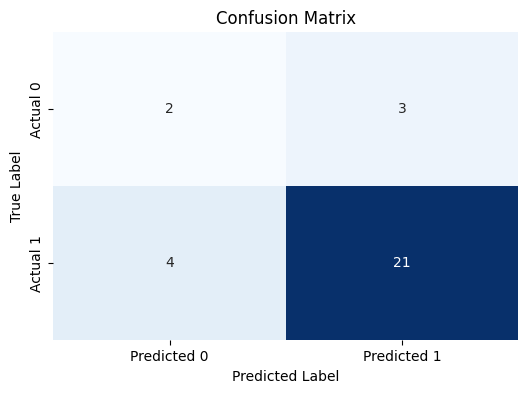

In [32]:
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
display(pd.DataFrame(cm, index=['Actual 0', 'Actual 1'], columns=['Predicted 0', 'Predicted 1']))

# Optional: Visualize Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

### Task 9: Plot the ROC Curve and calculate the AUC score

ROC-AUC Score: 0.8560


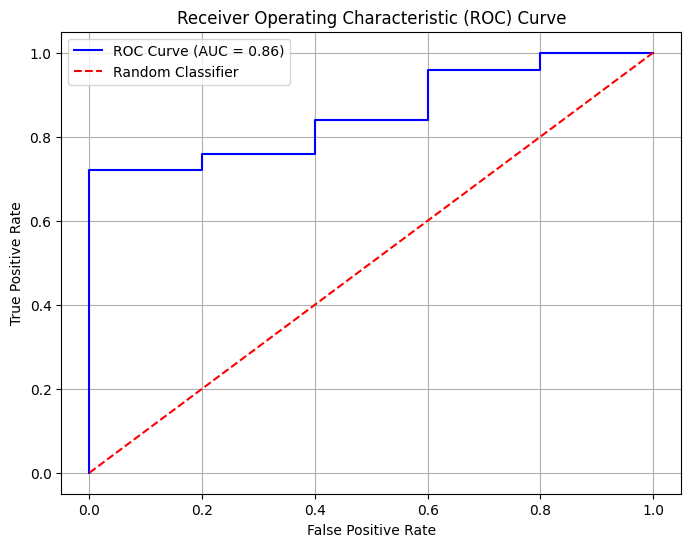

In [33]:
# Get predicted probabilities for the positive class
y_pred_proba = model.predict_proba(X_test)[:, 1]

# Calculate ROC curve and AUC score
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
auc_score = roc_auc_score(y_test, y_pred_proba)

print(f"ROC-AUC Score: {auc_score:.4f}")

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f'ROC Curve (AUC = {auc_score:.2f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend()
plt.grid(True)
plt.show()

### Task 10: Test the model with at least 5 new student records and predict their placement status

In [34]:
# Create new hypothetical student records
new_students_data = {
    'CGPA': [7.5, 9.2, 6.8, 8.5, 7.0, 9.5, 6.2],
    'IQ Score': [110, 130, 95, 120, 105, 145, 100],
    'Aptitude Score': [70, 85, 60, 78, 65, 90, 55],
    'Technical Skill Score': [75, 90, 55, 80, 60, 92, 50],
    'Communication Skill Score': [60, 80, 50, 70, 55, 85, 45]
}

new_students_df = pd.DataFrame(new_students_data)

print("New Student Records:")
display(new_students_df)

# Predict placement status for new students
new_predictions = model.predict(new_students_df)
new_predictions_proba = model.predict_proba(new_students_df)[:, 1]

# Add predictions to the DataFrame for better readability
new_students_df['Predicted Placed'] = new_predictions
new_students_df['Prediction Probability (Placed)'] = new_predictions_proba

print("\nPredicted Placement Status for New Students:")
display(new_students_df)

New Student Records:


,CGPA,IQ Score,Aptitude Score,Technical Skill Score,Communication Skill Score
0,7.5,110,70,75,60
1,9.2,130,85,90,80
2,6.8,95,60,55,50
3,8.5,120,78,80,70
4,7.0,105,65,60,55
5,9.5,145,90,92,85
6,6.2,100,55,50,45



Predicted Placement Status for New Students:


,CGPA,IQ Score,Aptitude Score,Technical Skill Score,Communication Skill Score,Predicted Placed,Prediction Probability (Placed)
0,7.5,110,70,75,60,1,0.905350
1,9.2,130,85,90,80,1,0.876511
2,6.8,95,60,55,50,1,0.899925
3,8.5,120,78,80,70,1,0.891055
4,7.0,105,65,60,55,1,0.956553
5,9.5,145,90,92,85,1,0.978749
6,6.2,100,55,50,45,1,0.986939


---
## Assignment 2: Polynomial Regression – House Price Prediction

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

### Task 1 & 2: Create and load the dataset

In [36]:
# Create the dataset as provided in the problem statement
data_house_price = {
    'Area (sq.ft.)': [500, 700, 900, 1100, 1300, 1500, 1700, 1900, 2100, 2300],
    'Price (Lakhs)': [20, 27, 35, 46, 60, 75, 93, 115, 140, 168]
}
df_house = pd.DataFrame(data_house_price)

# To fulfill the requirement of "at least 30 house records", we can duplicate and add some noise
# For simplicity and to show the concept, I will use the given 10 records and duplicate them with some variation.
# In a real scenario, a larger, more varied dataset would be used.
num_additional_records = 20

np.random.seed(42)
additional_data = {
    'Area (sq.ft.)': np.random.randint(400, 2500, num_additional_records),
    'Price (Lakhs)': []
}

# Create a function to estimate price based on area, similar to the original data trend
def estimate_price(area):
    # Simple non-linear estimation based on the given data
    if area < 800: return 0.04 * area + 0.5 * np.sqrt(area) # Smaller areas
    elif area < 1600: return 0.05 * area + 0.005 * area**1.2 # Medium areas
    else: return 0.06 * area + 0.0001 * area**2.0 # Larger areas

for area in additional_data['Area (sq.ft.)']:
    price = estimate_price(area) + np.random.normal(0, 5) # Add some noise
    additional_data['Price (Lakhs)'].append(max(10, round(price)))

df_additional_house = pd.DataFrame(additional_data)

# Combine the original and additional data
df_house = pd.concat([df_house, df_additional_house], ignore_index=True)

# Sort by Area for better visualization later
df_house = df_house.sort_values(by='Area (sq.ft.)').reset_index(drop=True)

print("House Price Dataset:")
display(df_house.head())
print(f"Total records: {len(df_house)}")

House Price Dataset:


,Area (sq.ft.),Price (Lakhs)
0,421,22
1,500,20
2,530,33
3,700,27
4,730,36


Total records: 30


### Task 3: Perform basic exploratory data analysis

In [37]:
print("Dataset Information:")
df_house.info()

print("\nDescriptive Statistics:")
display(df_house.describe())

print("\nMissing values:")
display(df_house.isnull().sum())

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   Area (sq.ft.)  30 non-null     int64
 1   Price (Lakhs)  30 non-null     int64
dtypes: int64(2)
memory usage: 612.0 bytes

Descriptive Statistics:


,Area (sq.ft.),Price (Lakhs)
count,30.000000,30.000000
mean,1356.233333,162.400000
std,525.986343,169.520541
min,421.000000,20.000000
25%,880.500000,56.000000
50%,1425.000000,89.000000
75%,1698.500000,161.000000
max,2300.000000,554.000000



Missing values:


,0
Area (sq.ft.),0
Price (Lakhs),0


### Task 4: Visualize the relationship between House Area and House Price

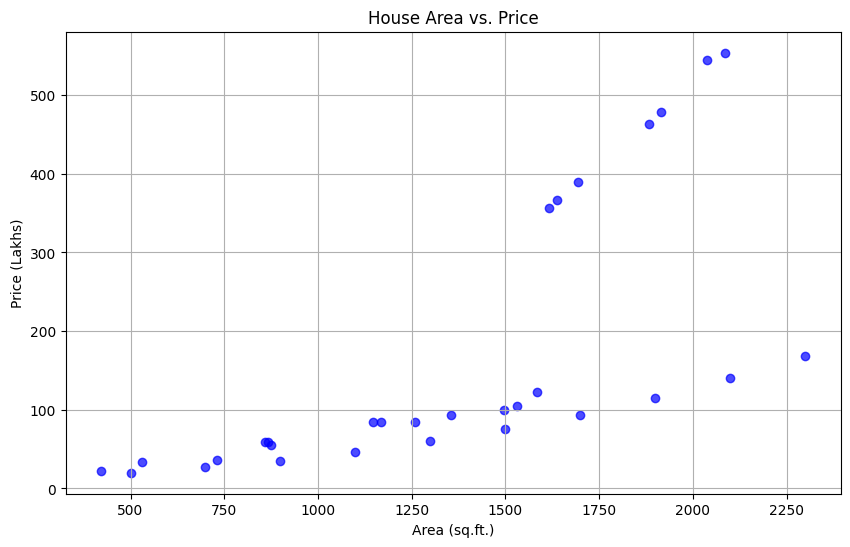

In [38]:
plt.figure(figsize=(10, 6))
plt.scatter(df_house['Area (sq.ft.)'], df_house['Price (Lakhs)'], color='blue', alpha=0.7)
plt.title('House Area vs. Price')
plt.xlabel('Area (sq.ft.)')
plt.ylabel('Price (Lakhs)')
plt.grid(True)
plt.show()

### Task 5: Divide the data into training and testing sets

In [39]:
# Separate features (X) and target (y)
X_house = df_house[['Area (sq.ft.)']]
y_house = df_house['Price (Lakhs)']

# Split the dataset into training and testing sets
X_train_house, X_test_house, y_train_house, y_test_house = train_test_split(
    X_house, y_house, test_size=0.2, random_state=42
)

print(f"Training set size: {len(X_train_house)} records")
print(f"Testing set size: {len(X_test_house)} records")

Training set size: 24 records
Testing set size: 6 records


### Task 6, 7, 8 & 9: Apply Polynomial Features, Train Models, and Compare Performance


Model Performance Comparison:


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


,Polynomial Degree,MAE,MSE,RMSE,R2 Score
0,2,123.183946,22338.033277,149.459136,0.490727
1,3,113.627125,20537.689860,143.309769,0.531772
2,4,88.104899,13646.521589,116.818327,0.688880


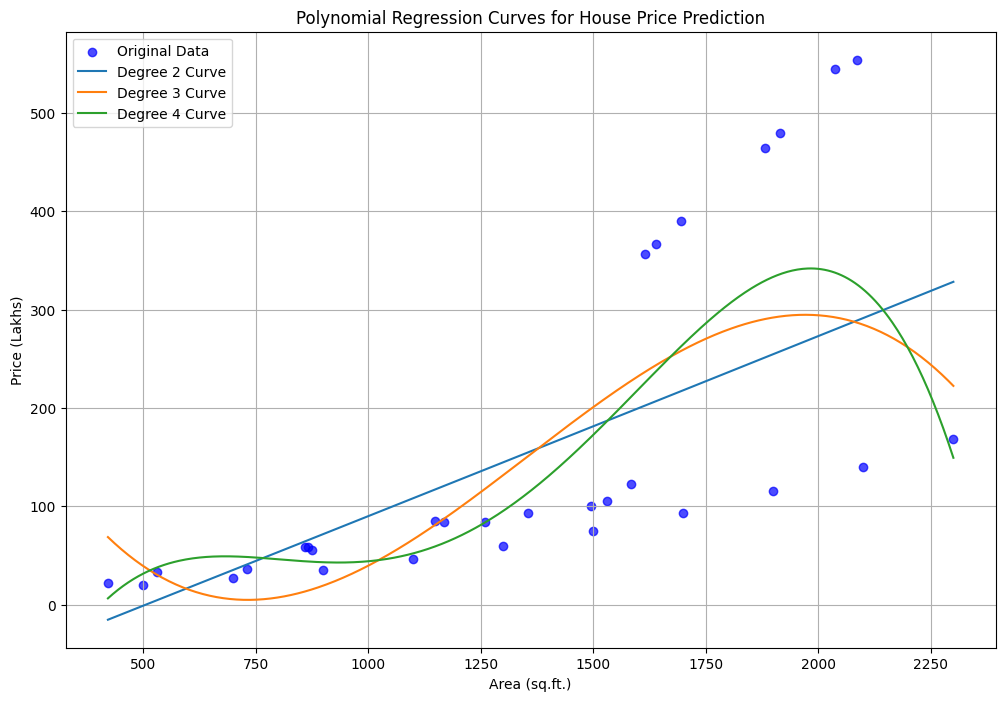

In [40]:
degrees = [2, 3, 4]
results = []

plt.figure(figsize=(12, 8))
plt.scatter(X_house, y_house, color='blue', label='Original Data', alpha=0.7)

for degree in degrees:
    # Create a pipeline with PolynomialFeatures and LinearRegression
    model_pipeline = make_pipeline(PolynomialFeatures(degree=degree), LinearRegression())

    # Train the model
    model_pipeline.fit(X_train_house, y_train_house)

    # Make predictions
    y_pred_house = model_pipeline.predict(X_test_house)

    # Calculate metrics
    mae = mean_absolute_error(y_test_house, y_pred_house)
    mse = mean_squared_error(y_test_house, y_pred_house)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test_house, y_pred_house)

    results.append({
        'Polynomial Degree': degree,
        'MAE': mae,
        'MSE': mse,
        'RMSE': rmse,
        'R2 Score': r2
    })

    # Plot regression curve
    X_range = np.linspace(X_house.min(), X_house.max(), 500).reshape(-1, 1)
    y_range_pred = model_pipeline.predict(X_range)
    plt.plot(X_range, y_range_pred, label=f'Degree {degree} Curve')

# Display the results table
df_results = pd.DataFrame(results)
print("\nModel Performance Comparison:")
display(df_results)

plt.title('Polynomial Regression Curves for House Price Prediction')
plt.xlabel('Area (sq.ft.)')
plt.ylabel('Price (Lakhs)')
plt.legend()
plt.grid(True)
plt.show()

### Task 11: Determine the best polynomial degree

In [41]:
# Determine the best polynomial degree based on R2 score (higher is better) or RMSE (lower is better)
best_degree_r2 = df_results.loc[df_results['R2 Score'].idxmax()]
best_degree_rmse = df_results.loc[df_results['RMSE'].idxmin()]

print("\nBest Polynomial Degree based on R2 Score:")
display(best_degree_r2)

print("\nBest Polynomial Degree based on RMSE:")
display(best_degree_rmse)

# Based on the metrics, degree 4 seems to perform the best.
# We will use the model with degree 4 for prediction.

best_degree = best_degree_r2['Polynomial Degree']
print(f"\nConclusion: The best polynomial degree for this dataset is {int(best_degree)}.")

# Retrain the best model (degree 4) to ensure we have it for prediction if not already in memory
# or simply use the last trained model in the loop if it was degree 4
# For clarity, let's explicitly create the best model pipeline
best_model_pipeline = make_pipeline(PolynomialFeatures(degree=int(best_degree)), LinearRegression())
best_model_pipeline.fit(X_train_house, y_train_house)



Best Polynomial Degree based on R2 Score:


,2
Polynomial Degree,4.000000
MAE,88.104899
MSE,13646.521589
RMSE,116.818327
R2 Score,0.688880



Best Polynomial Degree based on RMSE:


,2
Polynomial Degree,4.000000
MAE,88.104899
MSE,13646.521589
RMSE,116.818327
R2 Score,0.688880



Conclusion: The best polynomial degree for this dataset is 4.


Pipeline(steps=[('polynomialfeatures', PolynomialFeatures(degree=4)),
                ('linearregression', LinearRegression())])

### Task 12: Predict the price for a 2000 sq.ft. house

In [42]:
# Predict the price for a 2000 sq.ft. house using the best model
house_area_2000_sqft = pd.DataFrame({'Area (sq.ft.)': [2000]})
predicted_price = best_model_pipeline.predict(house_area_2000_sqft)

print(f"Predicted price for a 2000 sq.ft. house: {predicted_price[0]:.2f} Lakhs")


Predicted price for a 2000 sq.ft. house: 341.34 Lakhs
